In [24]:
from pathlib import Path
import json, random, warnings
from datetime import datetime

import numpy as np

warnings.filterwarnings("ignore")

SEED        = 42
TEST_SIZE   = 0.2
CV_FOLDS    = 5
EXPERIMENT  = "Iris_CatBoost_Lab"

PROJECT_ROOT = Path('.')
MODELS_DIR   = PROJECT_ROOT / 'models'
METRICS_DIR  = PROJECT_ROOT / 'metrics'
MLRUNS_DIR   = PROJECT_ROOT / 'mlruns'

for d in (MODELS_DIR, METRICS_DIR, MLRUNS_DIR):
    d.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
random.seed(SEED)

def now_ts() -> str:
    return datetime.now().strftime('%Y%m%d%H%M%S')

In [25]:
import pandas as pd
from sklearn.datasets import load_iris

dataset = load_iris()
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name="target")

class_map = {i: n for i, n in enumerate(dataset.target_names)}
df = X.copy()
df['target'] = y
df['species'] = df['target'].map(class_map)

print(f"Samples : {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Classes : {list(class_map.values())}")
df.head()

Samples : 150
Features: 4
Classes : ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


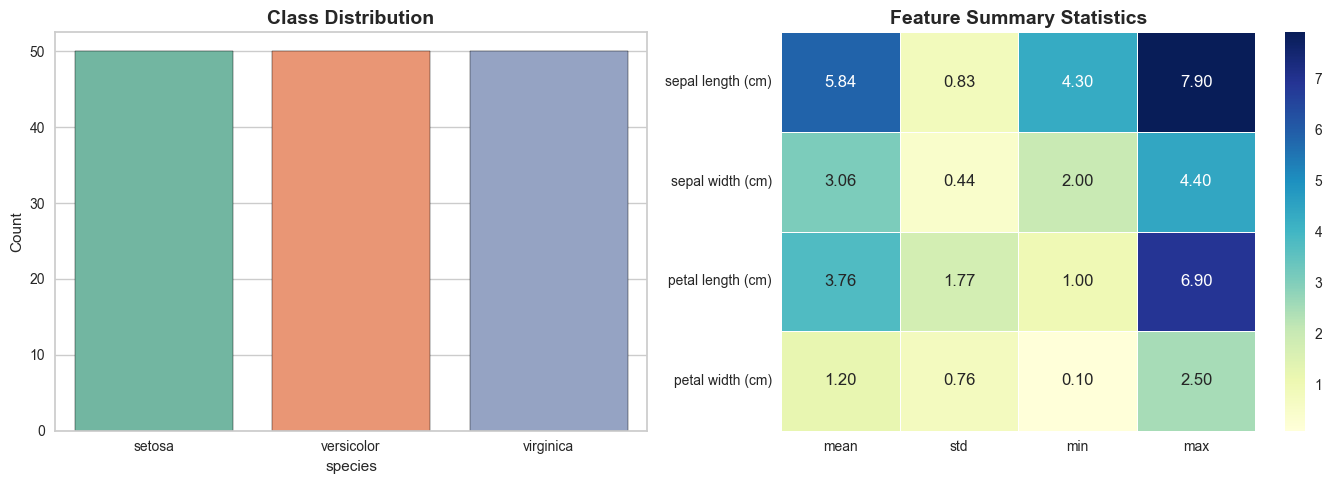

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class counts
sns.countplot(x='species', data=df, ax=axes[0], palette='Set2', edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

# Descriptive stats as a heatmap
desc = df.drop(columns=['target', 'species']).describe().T
sns.heatmap(desc[['mean', 'std', 'min', 'max']], annot=True, fmt='.2f',
            cmap='YlGnBu', ax=axes[1], linewidths=0.5)
axes[1].set_title('Feature Summary Statistics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

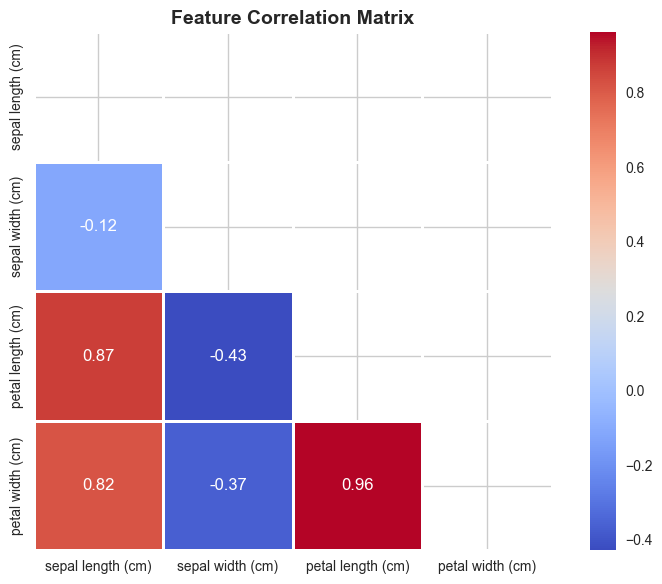

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.drop(columns=['target', 'species']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=1, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

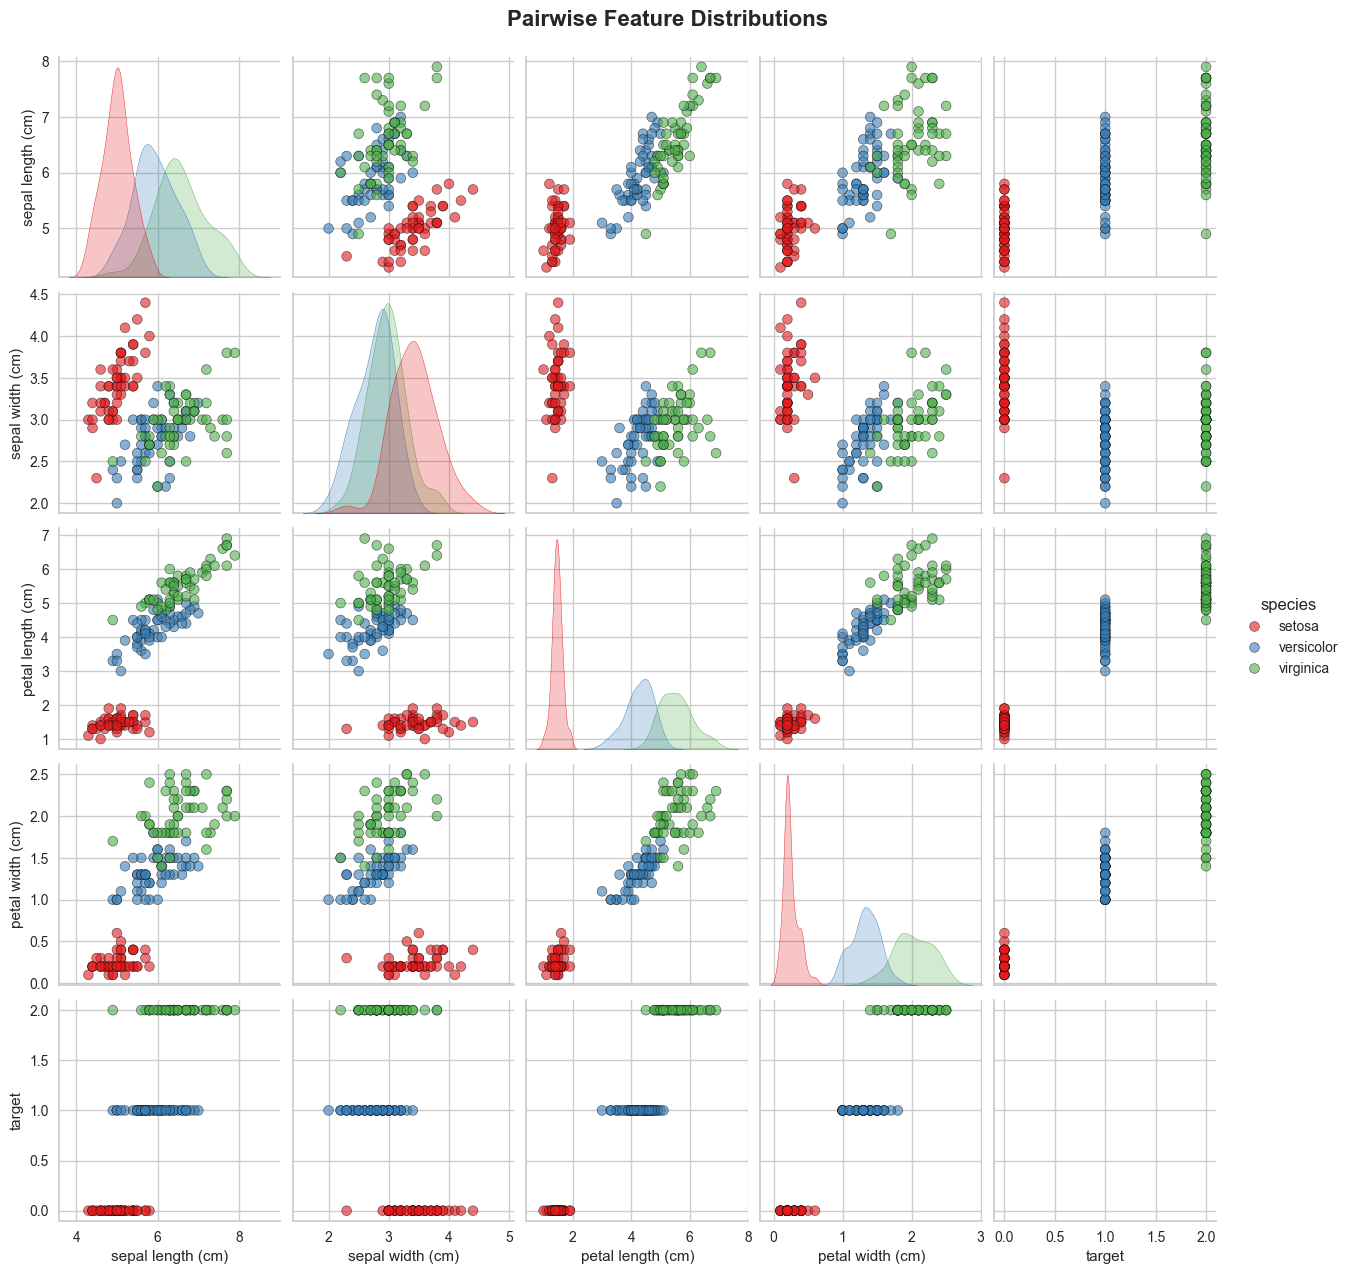

In [28]:
g = sns.pairplot(df, hue='species', palette='Set1', diag_kind='kde',
                 plot_kws={'alpha': 0.6, 'edgecolor': 'k', 'linewidth': 0.5})
g.figure.suptitle('Pairwise Feature Distributions', y=1.02, fontsize=16, fontweight='bold')
plt.show()

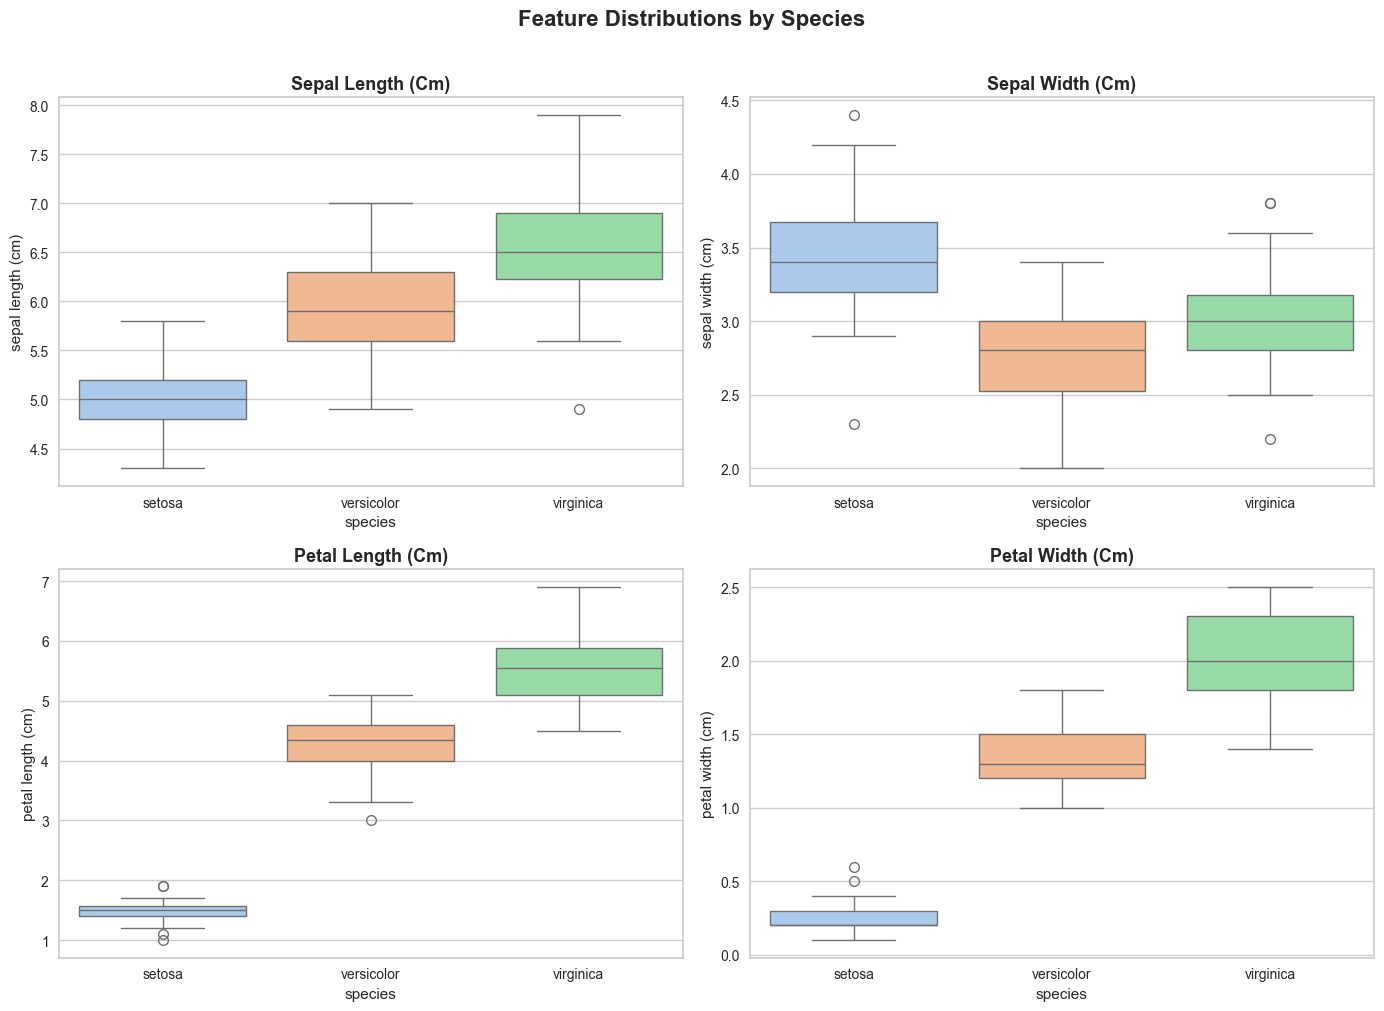

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), dataset.feature_names):
    sns.boxplot(x='species', y=col, data=df, ax=ax, palette='pastel')
    ax.set_title(col.title(), fontsize=13, fontweight='bold')
plt.suptitle('Feature Distributions by Species', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)
print(f"Train set: {X_train.shape[0]}  |  Test set: {X_test.shape[0]}")

Train set: 120  |  Test set: 30


In [31]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

cat_base = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=SEED,
    verbose=0,
)

param_distributions = {
    'iterations':          randint(50, 300),
    'learning_rate':       uniform(0.01, 0.29),   
    'depth':               randint(3, 10),
    'l2_leaf_reg':         uniform(1.0, 9.0),
    'border_count':        randint(32, 255),
    'bagging_temperature': uniform(0.0, 1.0),
}

search = RandomizedSearchCV(
    estimator=cat_base,
    param_distributions=param_distributions,
    n_iter=30,
    cv=CV_FOLDS,
    scoring='accuracy',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

best_params = search.best_params_
print(f"\nBest CV Accuracy : {search.best_score_:.4f}")
print(f"Best Parameters    : {json.dumps(best_params, indent=2)}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV Accuracy : 0.9667
Best Parameters    : {
  "bagging_temperature": 0.6476901205413623,
  "border_count": 152,
  "depth": 6,
  "iterations": 254,
  "l2_leaf_reg": 8.74657524930709,
  "learning_rate": 0.012016117854045303
}


In [32]:
tuning_df = (
    pd.DataFrame(search.cv_results_)
    .sort_values('rank_test_score')
    [['rank_test_score', 'mean_test_score', 'std_test_score', 'params']]
    .head(10)
    .reset_index(drop=True)
)
tuning_df.columns = ['Rank', 'Mean Accuracy', 'Std', 'Params']
tuning_df.style.format({'Mean Accuracy': '{:.4f}', 'Std': '{:.4f}'}).background_gradient(cmap='Greens', subset=['Mean Accuracy'])

,Rank,Mean Accuracy,Std,Params
0,1,0.9667,0.0167,"{'bagging_temperature': 0.6476901205413623, 'border_count': 152, 'depth': 6, 'iterations': 254, 'l2_leaf_reg': 8.74657524930709, 'learning_rate': 0.012016117854045303}"
1,2,0.9583,0.0264,"{'bagging_temperature': 0.3745401188473625, 'border_count': 124, 'depth': 9, 'iterations': 156, 'l2_leaf_reg': 8.017219002454922, 'learning_rate': 0.18308654580448122}"
2,2,0.9583,0.0264,"{'bagging_temperature': 0.45653457048291024, 'border_count': 139, 'depth': 6, 'iterations': 133, 'l2_leaf_reg': 9.0330309864098, 'learning_rate': 0.1664092501555387}"
3,2,0.9583,0.0000,"{'bagging_temperature': 0.16122128725400442, 'border_count': 97, 'depth': 4, 'iterations': 94, 'l2_leaf_reg': 3.660703172539426, 'learning_rate': 0.04059333535077848}"
4,2,0.9583,0.0264,"{'bagging_temperature': 0.7607850486168974, 'border_count': 249, 'depth': 9, 'iterations': 191, 'l2_leaf_reg': 5.444160367279517, 'learning_rate': 0.16159252052077827}"
5,2,0.9583,0.0264,"{'bagging_temperature': 0.3584657285442726, 'border_count': 72, 'depth': 6, 'iterations': 184, 'l2_leaf_reg': 8.650347200108193, 'learning_rate': 0.140340695500079}"
6,2,0.9583,0.0264,"{'bagging_temperature': 0.014079822715084456, 'border_count': 112, 'depth': 5, 'iterations': 212, 'l2_leaf_reg': 7.941433120173512, 'learning_rate': 0.031472949002886205}"
7,2,0.9583,0.0000,"{'bagging_temperature': 0.07455064367977082, 'border_count': 102, 'depth': 3, 'iterations': 137, 'l2_leaf_reg': 4.5539336635801275, 'learning_rate': 0.09511157066823105}"
8,2,0.9583,0.0264,"{'bagging_temperature': 0.5107473025775657, 'border_count': 168, 'depth': 8, 'iterations': 214, 'l2_leaf_reg': 7.2319242960124335, 'learning_rate': 0.08812957680157121}"
9,2,0.9583,0.0264,"{'bagging_temperature': 0.9611720243493491, 'border_count': 244, 'depth': 7, 'iterations': 131, 'l2_leaf_reg': 5.857229191501718, 'learning_rate': 0.18015783804251598}"


In [33]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

best_model = CatBoostClassifier(
    **best_params,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=SEED,
    verbose=0,
)
best_model.fit(X_train, y_train)

y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)

metrics = {
    'accuracy':  float(accuracy_score(y_test, y_pred)),
    'precision': float(precision_score(y_test, y_pred, average='weighted')),
    'recall':    float(recall_score(y_test, y_pred,    average='weighted')),
    'f1':        float(f1_score(y_test, y_pred,        average='weighted')),
    'roc_auc':   float(roc_auc_score(y_test, y_pred_prob, multi_class='ovr')),
}

print("Final Test Metrics")
print(json.dumps(metrics, indent=2))

Final Test Metrics
{
  "accuracy": 0.9333333333333333,
  "precision": 0.9333333333333333,
  "recall": 0.9333333333333333,
  "f1": 0.9333333333333333,
  "roc_auc": 0.9899999999999999
}


In [34]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.multiclass import type_of_target

class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make CatBoost compatible with Yellowbrick visualizers."""
    
    def __init__(self, model):
        self.model = model
        self.classes_ = None
        self.target_type_ = None
        self._target_color_type = None
    
    def fit(self, X, y, **kwargs):
        self.model.fit(X, y, **kwargs)
        self.classes_ = self.model.classes_
        self._set_target_type(y)
        return self
    
    def _set_target_type(self, y):
        """Set target type attributes required by Yellowbrick."""
        self.target_type_ = type_of_target(y)
        # Map target type to color type for ROCAUC
        if self.target_type_ == 'binary':
            self._target_color_type = 'binary'
        elif self.target_type_ in ('multiclass', 'multiclass-multioutput'):
            self._target_color_type = 'multiclass'
        else:
            self._target_color_type = self.target_type_
    
    def predict(self, X):
        return self.model.predict(X)
    
    def predict_proba(self, X):
        return self.model.predict_proba(X)
    
    @property
    def _estimator_type(self):
        return "classifier"


wrapped_model = CatBoostWrapper(best_model)
wrapped_model.classes_ = best_model.classes_

wrapped_model.target_type_ = 'multiclass'
wrapped_model._target_color_type = 'multiclass'


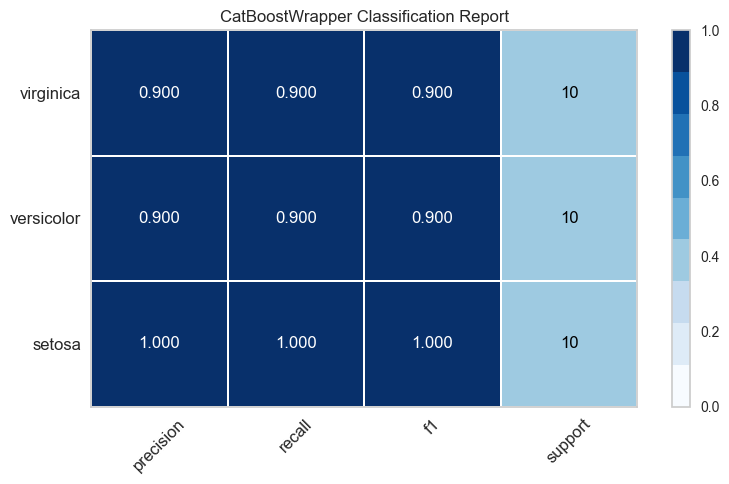

In [35]:
from yellowbrick.classifier import ClassificationReport

fig, ax = plt.subplots(figsize=(8, 5))
viz = ClassificationReport(
    wrapped_model,
    classes=dataset.target_names,
    support=True,
    cmap='Blues',
    ax=ax,
    is_fitted=True
)
viz.score(X_test, y_test)
viz.finalize()
cr_path = METRICS_DIR / 'classification_report_latest.png'
fig.savefig(cr_path, dpi=150, bbox_inches='tight')
plt.show()

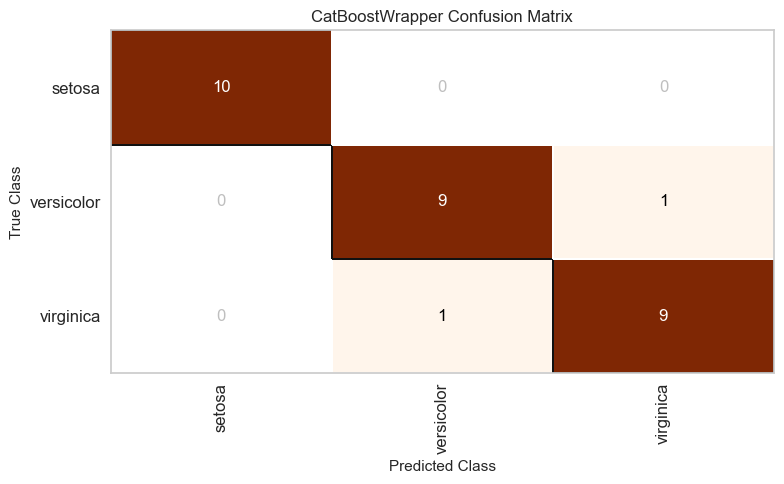

In [36]:
from yellowbrick.classifier import ConfusionMatrix

fig, ax = plt.subplots(figsize=(8, 5))
viz = ConfusionMatrix(wrapped_model, classes=dataset.target_names, cmap='Oranges', ax=ax)
viz.score(X_test, y_test)
viz.finalize()
cm_path = METRICS_DIR / 'confusion_matrix_latest.png'
fig.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

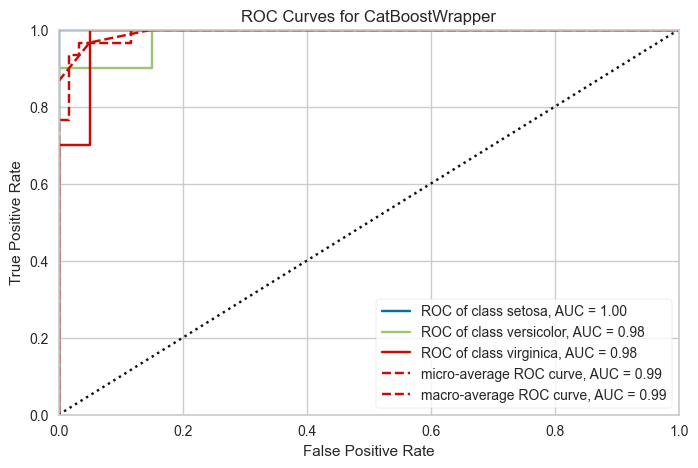

In [37]:
from yellowbrick.classifier import ROCAUC

fig, ax = plt.subplots(figsize=(8, 5))
viz = ROCAUC(wrapped_model, classes=dataset.target_names, ax=ax)
viz.score(X_test, y_test)
viz.finalize()
roc_path = METRICS_DIR / 'roc_curve_latest.png'
fig.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()

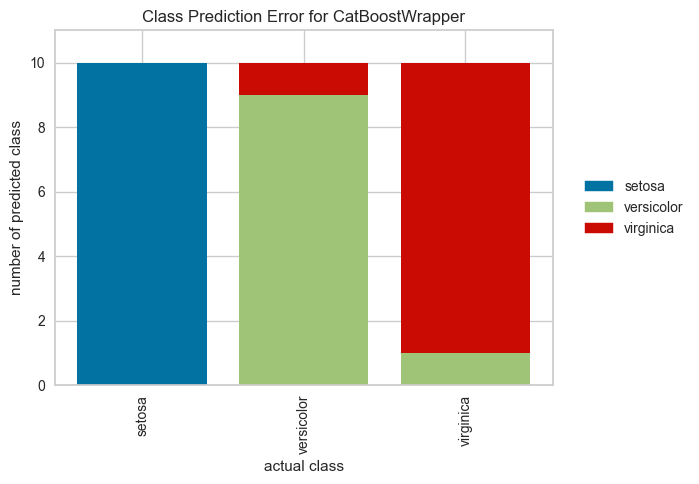

In [38]:
from yellowbrick.classifier import ClassPredictionError

fig, ax = plt.subplots(figsize=(8, 5))
viz = ClassPredictionError(wrapped_model, classes=dataset.target_names, ax=ax)
viz.score(X_test, y_test)
viz.finalize()
cpe_path = METRICS_DIR / 'class_prediction_error_latest.png'
fig.savefig(cpe_path, dpi=150, bbox_inches='tight')
plt.show()

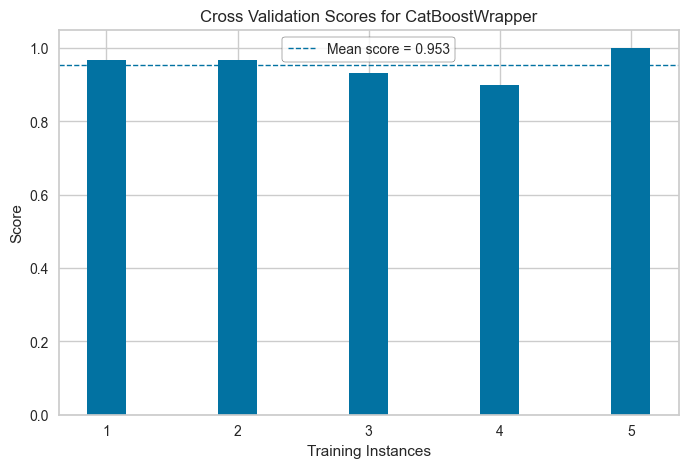

In [39]:
from yellowbrick.model_selection import CVScores

fig, ax = plt.subplots(figsize=(8, 5))
viz = CVScores(wrapped_model, cv=CV_FOLDS, scoring='f1_weighted', ax=ax)
viz.fit(X, y)
viz.finalize()
cv_path = METRICS_DIR / 'cv_scores_latest.png'
fig.savefig(cv_path, dpi=150, bbox_inches='tight')
plt.show()

In [40]:
import mlflow
from mlflow.models.signature import infer_signature
from joblib import dump

mlflow.set_tracking_uri(f"sqlite:///{MLRUNS_DIR.resolve()}/mlflow.db")
mlflow.set_experiment(EXPERIMENT)

run_name = f"CatBoost_{now_ts()}"

with mlflow.start_run(run_name=run_name):
    # — params
    mlflow.log_params(best_params)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("cv_folds", CV_FOLDS)
    mlflow.log_param("tuning_iterations", 30)
    
    # — metrics
    mlflow.log_metrics(metrics)
    
    # — model with signature
    signature = infer_signature(X_train, best_model.predict(X_train))
    mlflow.catboost.log_model(
        cb_model=best_model,
        artifact_path="catboost-model",
        signature=signature,
        input_example=X_train.head(1),
    )
    
    # — save joblib locally too
    ts = now_ts()
    local_model = MODELS_DIR / f'model_{ts}_catboost.joblib'
    dump(best_model, local_model)
    
    # — metrics JSON
    metrics_json = METRICS_DIR / f'{ts}_metrics.json'
    with open(metrics_json, 'w') as f:
        json.dump(metrics, f, indent=2)
    mlflow.log_artifact(str(metrics_json), "metrics")
    
    # — plots
    for p in (cr_path, cm_path, roc_path, cpe_path, cv_path):
        mlflow.log_artifact(str(p), "evaluation_plots")

print(f"✅ Run '{run_name}' logged to MLflow")


2026/03/14 06:19:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 06:19:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Run 'CatBoost_20260314061902' logged to MLflow


In [41]:
required = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
assert required.issubset(metrics.keys()), "Missing metrics!"
for k in required:
    assert 0.0 <= metrics[k] <= 1.0, f"{k} out of range"
print("✅ All sanity checks passed")

✅ All sanity checks passed
